In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_nav = pd.read_csv('../data/processed/clean_nav.csv')
df_performance = pd.read_csv('../data/processed/clean_performance.csv')

In [5]:
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

print(df_nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [6]:
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

In [8]:
df_nav.to_csv('../data/processed/returns_computed.csv', index=False)
print("Daily returns computed and saved to returns_computed.csv successfully!")
df_nav.head()

Daily returns computed and saved to returns_computed.csv successfully!


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
Rf_annual = 0.065
sharpe_results = []

In [10]:
for code, group in df_nav.groupby('amfi_code'):
    ret = group['daily_return'].dropna()
    if len(ret) > 0:
        mean_ret_annual = ret.mean() * 252
        std_ret_annual = ret.std() * np.sqrt(252)
        sharpe = (mean_ret_annual - Rf_annual) / std_ret_annual if std_ret_annual != 0 else 0
        sharpe_results.append({'amfi_code': code, 'sharpe_ratio': sharpe})

In [11]:
df_sharpe = pd.DataFrame(sharpe_results)
df_sharpe.to_csv('../data/processed/sharpe_values.csv', index=False)
df_sharpe.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [12]:
sortino_results = []

In [13]:
for code, group in df_nav.groupby('amfi_code'):
    ret = group['daily_return'].dropna()
    if len(ret) > 0:
        mean_ret_annual = ret.mean() * 252
        downside_ret = ret[ret < 0]
        downside_std = downside_ret.std() * np.sqrt(252) if len(downside_ret) > 0 else 0
        sortino = (mean_ret_annual - Rf_annual) / downside_std if downside_std != 0 else 0
        sortino_results.append({'amfi_code': code, 'sortino_ratio': sortino})

In [14]:
df_sortino = pd.DataFrame(sortino_results)
df_sortino.to_csv('../data/processed/sortino_values.csv', index=False)
df_sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
dd_results = []

In [16]:
for code, group in df_nav.groupby('amfi_code'):
    nav = group['nav']
    running_max = nav.cummax()
    drawdown = (nav / running_max) - 1
    max_dd = drawdown.min()
    dd_results.append({'amfi_code': code, 'max_drawdown': max_dd})

In [17]:
df_dd = pd.DataFrame(dd_results)
df_dd.to_csv('../data/processed/max_drawdown.csv', index=False)
df_dd.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [18]:
df_scorecard = df_performance.copy()

In [19]:
df_scorecard = df_scorecard.merge(df_sharpe, on='amfi_code', how='left')
df_scorecard = df_scorecard.merge(df_sortino, on='amfi_code', how='left')
df_scorecard = df_scorecard.merge(df_dd, on='amfi_code', how='left')

In [21]:
print(df_scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x',
       'sortino_ratio_x', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore',
       'expense_ratio_pct', 'morningstar_rating', 'risk_grade',
       'negative_sharpe', 'sharpe_ratio_y', 'sortino_ratio_y', 'max_drawdown',
       'rank_3yr'],
      dtype='object')


In [24]:
df_scorecard.rename(columns={
    'sharpe_ratio_y': 'sharpe_ratio',
    'sortino_ratio_y': 'sortino_ratio'
}, inplace=True)

df_scorecard.drop(columns=[
    'sharpe_ratio_x',
    'sortino_ratio_x'
], inplace=True)

In [25]:
df_scorecard['rank_3yr'] = df_scorecard['return_3yr_pct'].rank(ascending=False)
df_scorecard['rank_sharpe'] = df_scorecard['sharpe_ratio'].rank(ascending=False)
df_scorecard['rank_alpha'] = df_scorecard['alpha'].rank(ascending=False)
df_scorecard['rank_expense'] = df_scorecard['expense_ratio_pct'].rank(ascending=True)
df_scorecard['rank_dd'] = df_scorecard['max_drawdown'].rank(ascending=False)

In [26]:
n = len(df_scorecard)
df_scorecard['composite_score'] = (
    0.30 * (1 - (df_scorecard['rank_3yr'] - 1) / n) +
    0.25 * (1 - (df_scorecard['rank_sharpe'] - 1) / n) +
    0.20 * (1 - (df_scorecard['rank_alpha'] - 1) / n) +
    0.15 * (1 - (df_scorecard['rank_expense'] - 1) / n) +
    0.10 * (1 - (df_scorecard['rank_dd'] - 1) / n)
) * 100

In [27]:
df_scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
df_scorecard[['amfi_code', 'scheme_name', 'composite_score']].head()

,amfi_code,scheme_name,composite_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,48.8125
1,119552,SBI Bluechip Fund - Direct Plan - Growth,60.7500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,66.1250
3,119599,SBI Small Cap Fund - Direct Plan - Growth,57.6875
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,39.7500


In [28]:
plt.figure(figsize=(10, 5))
sample_funds = df_nav['amfi_code'].unique()[:3]

<Figure size 1000x500 with 0 Axes>

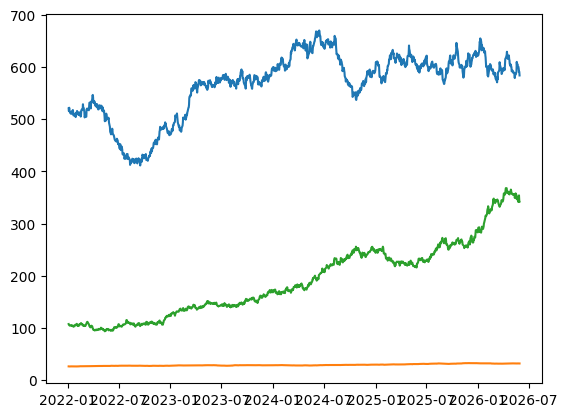

In [29]:
for code in sample_funds:
    subset = df_nav[df_nav['amfi_code'] == code]
    plt.plot(subset['date'], subset['nav'], label=f'Fund {code}')

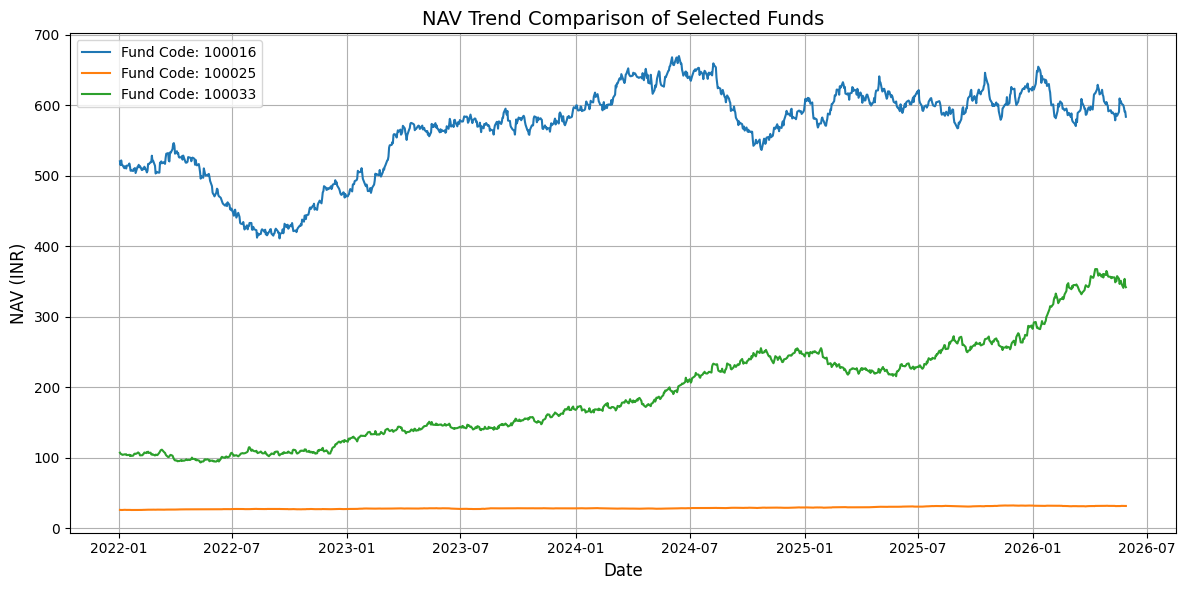

Chart generated and saved successfully!


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df_nav = pd.read_csv('../data/processed/clean_nav.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])

top_funds = df_nav['amfi_code'].unique()[:3]

plt.figure(figsize=(12, 6))

for code in top_funds:
    subset = df_nav[df_nav['amfi_code'] == code].sort_values('date')
    plt.plot(subset['date'], subset['nav'], label=f'Fund Code: {code}')

plt.title('NAV Trend Comparison of Selected Funds', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('NAV (INR)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('../reports/charts/benchmark_chart.png')
plt.show()
print("Chart generated and saved successfully!")

In [1]:
import pandas as pd
import numpy as np

df_nav = pd.read_csv('../data/processed/clean_nav.csv')
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

cagr_results = []

for code, group in df_nav.groupby('amfi_code'):
    group = group.sort_values('date').dropna(subset=['nav'])
    if len(group) < 2:
        continue

    end_date = group['date'].max()
    end_nav = group.loc[group['date'] == end_date, 'nav'].values[0]
    
    def get_past_nav(target_years):
        target_date = end_date - pd.DateOffset(years=target_years)
     
        sub = group[group['date'] <= target_date]
        if not sub.empty:
            closest_row = sub.iloc[-1]
            return closest_row['nav'], (end_date - closest_row['date']).days / 365.25
        else:
            
            earliest_row = group.iloc[0]
            return earliest_row['nav'], (end_date - earliest_row['date']).days / 365.25

    nav_1yr, yrs_1yr = get_past_nav(1)
    cagr_1yr = (end_nav / nav_1yr) ** (1 / yrs_1yr) - 1 if yrs_1yr > 0 else np.nan

    nav_3yr, yrs_3yr = get_past_nav(3)
    cagr_3yr = (end_nav / nav_3yr) ** (1 / yrs_3yr) - 1 if yrs_3yr > 0 else np.nan

    nav_5yr, yrs_5yr = get_past_nav(5)
    cagr_5yr = (end_nav / nav_5yr) ** (1 / yrs_5yr) - 1 if yrs_5yr > 0 else np.nan

    cagr_results.append({
        'amfi_code': code,
        'cagr_1yr': cagr_1yr,
        'cagr_3yr': cagr_3yr,
        'cagr_5yr': cagr_5yr
    })

df_cagr = pd.DataFrame(cagr_results)
df_cagr.to_csv('../data/processed/cagr_report.csv', index=False)
print("CAGR report generated and saved to cagr_report.csv successfully!")
df_cagr.head()

CAGR report generated and saved to cagr_report.csv successfully!


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-0.022258,0.012924,0.026371
1,100025,0.037076,0.039155,0.044582
2,100033,0.532772,0.324340,0.301232
3,101206,0.479638,0.289602,0.235384
4,101207,-0.240003,-0.041515,0.079388


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

df_nav = pd.read_csv('../data/processed/clean_nav.csv')
df_bench = pd.read_csv('10_benchmark_indices.csv')

df_nav['date'] = pd.to_datetime(df_nav['date'])
df_bench['date'] = pd.to_datetime(df_bench['date'])

df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].copy()
df_nifty100 = df_nifty100.sort_values('date')
df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()

if 'daily_return' not in df_nav.columns:
    df_nav = df_nav.sort_values(['amfi_code', 'date'])
    df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

alpha_beta_results = []

for code, group in df_nav.groupby('amfi_code'):
    merged = pd.merge(group, df_nifty100[['date', 'bench_return']], on='date', how='inner').dropna(subset=['daily_return', 'bench_return'])
    
    if len(merged) > 30: 
        slope, intercept, r_value, p_value, std_err = linregress(merged['bench_return'], merged['daily_return'])
        beta = slope
        alpha = intercept * 252 
        
        alpha_beta_results.append({
            'amfi_code': code,
            'alpha': alpha,
            'beta': beta
        })

df_alpha_beta = pd.DataFrame(alpha_beta_results)
df_alpha_beta.to_csv('../data/processed/alpha_beta.csv', index=False)
print("Alpha & Beta report generated and saved to alpha_beta.csv successfully!")
df_alpha_beta.head()

FileNotFoundError: [Errno 2] No such file or directory: '10_benchmark_indices.csv'